# Lung Nodules Classifier
Classifying nodule malignancy from the LIDC/IDRI MaxSlices dataset.

In [1]:
import pandas as pd
from pathlib import Path

DATA_PATH = Path("Data/LIDC_MaxSlices_cp_2024.xlsx")
df = pd.read_excel(DATA_PATH)
print("raw shape:", df.shape)
df.head()

raw shape: (2637, 126)


,Subtlety,InternalStructure,Calcification,Sphericity,Margin,Lobulation,Spiculation,Texture,Malignancy,new_noduleID,...,Homogeneity,Entropy,x_3rdordermoment,Inversevariance,Sumaverage,Variance,Clustertendency,MaxProbability,Manufacturer,Manufacturer_s_Model_Name
0,5,1.0,6.0,3,4,3,5,5,5,1,...,0.0532,8.15,1290000,0.0223,661.0,143000,541000,0.0009,GE Medical Systems,LightSpeed Plus
1,2,1.0,6.0,4,2,1,1,2,5,2,...,0.0567,7.76,11100000,0.0221,260.0,32700,115000,0.0012,GE Medical Systems,LightSpeed16
2,5,1.0,6.0,4,3,2,2,4,5,3,...,0.0572,8.03,735000,0.0247,416.0,111000,420000,0.0010,GE Medical Systems,LightSpeed16
3,4,1.0,6.0,4,4,1,2,5,4,4,...,0.0312,6.03,-469000,0.0107,420.0,98700,333000,0.0043,GE Medical Systems,LightSpeed16
4,4,1.0,6.0,5,5,1,1,5,4,5,...,0.0764,6.43,8600000,0.0392,565.0,137000,492000,0.0052,GE Medical Systems,LightSpeed16


## Drop Uneeded Features
Three groups are removed:
1. **Identifiers** — IDs, UIDs, file paths; no predictive value.
2. **Per-radiologist ratings** (`_1`..`_4` suffixes) — duplicates of the consensus columns, and `Malignancy_1..4` are target leakage.
3. **Scanner metadata** — describes the CT scanner, not the nodule (risks batch-effect shortcuts).

In [2]:
# 1. Identifier columns
id_cols = [
    "new_noduleID", "noduleID", "InstanceID",
    "StudyInstanceUID", "SeriesInstanceUid", "RadiologistID",
    "DicomImage", "FilePath", "imageZposition",
    "imageSOP_UID", "coords",
]

# 2. Per-radiologist rating columns (leakage + duplicates of consensus cols)
rating_bases = [
    "Subtlety", "InternalStructure", "Calcification", "Sphericity",
    "Margin", "Lobulation", "Spiculation", "Texture", "Malignancy",
]
per_radiologist_cols = [f"{base}_{i}" for base in rating_bases for i in range(1, 5)]

# 3. Scanner metadata
scanner_cols = ["Manufacturer", "Manufacturer_s_Model_Name"]

# all cols to drop
drop_cols = id_cols + per_radiologist_cols + scanner_cols

df = df.drop(columns=drop_cols)
print(f"dropped {len(drop_cols)} columns")
print("cleaned shape:", df.shape)
df.head()

dropped 49 columns
cleaned shape: (2637, 77)


,Subtlety,InternalStructure,Calcification,Sphericity,Margin,Lobulation,Spiculation,Texture,Malignancy,PixelSpacing,...,Correlation,Energy,Homogeneity,Entropy,x_3rdordermoment,Inversevariance,Sumaverage,Variance,Clustertendency,MaxProbability
0,5,1.0,6.0,3,4,3,5,5,5,0.703125,...,0.894,0.0003,0.0532,8.15,1290000,0.0223,661.0,143000,541000,0.0009
1,2,1.0,6.0,4,2,1,1,2,5,0.681641,...,0.781,0.0005,0.0567,7.76,11100000,0.0221,260.0,32700,115000,0.0012
2,5,1.0,6.0,4,3,2,2,4,5,0.820312,...,0.899,0.0004,0.0572,8.03,735000,0.0247,416.0,111000,420000,0.0010
3,4,1.0,6.0,4,4,1,2,5,4,0.820312,...,0.692,0.0027,0.0312,6.03,-469000,0.0107,420.0,98700,333000,0.0043
4,4,1.0,6.0,5,5,1,1,5,4,0.820312,...,0.793,0.0018,0.0764,6.43,8600000,0.0392,565.0,137000,492000,0.0052


# Deciding What to Predict and More Proccessing

In this case the malignancy is on a scale of 1-5 which would not be ideal for a binary classifier. To account for this I am combining 
the 1-2 rated malignant data, dropping the 3 rated data (intermediate rating), and then finally combining the 4-5 rated data. 

This will give me the binary output of 0: benign and 1: malignant

| Benign | Malignant |
|--------|-----------|
| Rating 1-2 | Rating 4-5 |
| 0 | 1 | 


In [3]:
df = df[df['Malignancy'] != 3].copy()   # dropping the intermediate rows
df['Malignancy'] = df['Malignancy'].map({1: 0, 2: 0, 4: 1, 5: 1})   # mapping the labels to binary
print("after dropping intermediate malignancy rows shape:", df.shape)
df.head()


after dropping intermediate malignancy rows shape: (1456, 77)


,Subtlety,InternalStructure,Calcification,Sphericity,Margin,Lobulation,Spiculation,Texture,Malignancy,PixelSpacing,...,Correlation,Energy,Homogeneity,Entropy,x_3rdordermoment,Inversevariance,Sumaverage,Variance,Clustertendency,MaxProbability
0,5,1.0,6.0,3,4,3,5,5,1,0.703125,...,0.894,0.0003,0.0532,8.15,1290000,0.0223,661.0,143000,541000,0.0009
1,2,1.0,6.0,4,2,1,1,2,1,0.681641,...,0.781,0.0005,0.0567,7.76,11100000,0.0221,260.0,32700,115000,0.0012
2,5,1.0,6.0,4,3,2,2,4,1,0.820312,...,0.899,0.0004,0.0572,8.03,735000,0.0247,416.0,111000,420000,0.0010
3,4,1.0,6.0,4,4,1,2,5,1,0.820312,...,0.692,0.0027,0.0312,6.03,-469000,0.0107,420.0,98700,333000,0.0043
4,4,1.0,6.0,5,5,1,1,5,1,0.820312,...,0.793,0.0018,0.0764,6.43,8600000,0.0392,565.0,137000,492000,0.0052


# Train-Test split and Missing Value Handling

In [4]:
# missing value handling — drop the rows with the missing values in them
df = df.dropna()
print("after dropping missing values shape:", df.shape) 
df.head()

after dropping missing values shape: (1403, 77)


,Subtlety,InternalStructure,Calcification,Sphericity,Margin,Lobulation,Spiculation,Texture,Malignancy,PixelSpacing,...,Correlation,Energy,Homogeneity,Entropy,x_3rdordermoment,Inversevariance,Sumaverage,Variance,Clustertendency,MaxProbability
0,5,1.0,6.0,3,4,3,5,5,1,0.703125,...,0.894,0.0003,0.0532,8.15,1290000,0.0223,661.0,143000,541000,0.0009
1,2,1.0,6.0,4,2,1,1,2,1,0.681641,...,0.781,0.0005,0.0567,7.76,11100000,0.0221,260.0,32700,115000,0.0012
2,5,1.0,6.0,4,3,2,2,4,1,0.820312,...,0.899,0.0004,0.0572,8.03,735000,0.0247,416.0,111000,420000,0.0010
3,4,1.0,6.0,4,4,1,2,5,1,0.820312,...,0.692,0.0027,0.0312,6.03,-469000,0.0107,420.0,98700,333000,0.0043
4,4,1.0,6.0,5,5,1,1,5,1,0.820312,...,0.793,0.0018,0.0764,6.43,8600000,0.0392,565.0,137000,492000,0.0052


In [5]:
# train test split
from sklearn.model_selection import train_test_split

# Malignancy is the target, so it must be removed from the feature set X
X = df.drop(columns=["Malignancy"])
y = df["Malignancy"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("X_train:", X_train.shape, " X_test:", X_test.shape)


X_train: (1122, 76)  X_test: (281, 76)


# Initial Fitting to the Classifier

The inital fitting of the Decision Tree Classifier along with some metrics. 

In [6]:
# fitting the classifier
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# evaluating the classifier
from sklearn.metrics import classification_report
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.84      0.87       170
           1       0.78      0.86      0.82       111

    accuracy                           0.85       281
   macro avg       0.84      0.85      0.85       281
weighted avg       0.86      0.85      0.85       281



# Cross Validation 

Cross validation score for the current model using a Decision Tree Classifier


In [7]:
# cross validation score
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(model, X, y, cv=5)
print("Cross-validation scores:", cv_scores)
print("Mean CV score:", cv_scores.mean())

Cross-validation scores: [0.84697509 0.87544484 0.81850534 0.81428571 0.83928571]
Mean CV score: 0.8388993390950686


# Confusion Matrix as a Seaborn Heatmap

Now here is a confusion matrix for the inital model

Text(50.722222222222214, 0.5, 'Actual')

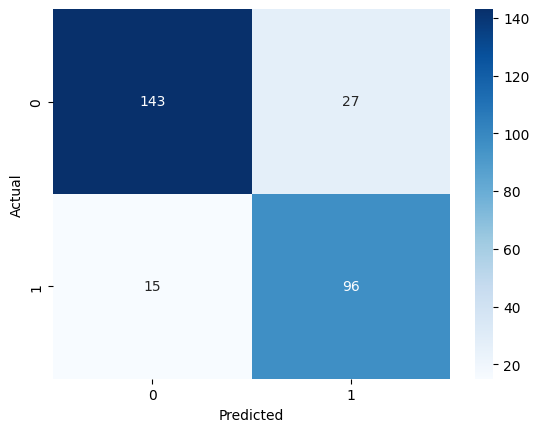

In [11]:
# confusion matrix using the heatmap
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')


# Interpreting the Features

Now with that I want to look within the Decision Tree and determine which features are driving Malignancy.

In [8]:
# checking the feature importances
feature_importances = pd.Series(model.feature_importances_, index=X.columns)
print("Feature importances:")
print(feature_importances.sort_values(ascending=False))

Feature importances:
ConvexArea        0.575033
Calcification     0.086629
Contrast          0.020766
MeanIntensity     0.015788
PixelSpacing      0.015025
                    ...   
Eccentricity      0.000000
Extent            0.000000
MinIntensityBG    0.000000
MaxIntensityBG    0.000000
markov3           0.000000
Length: 76, dtype: float64
